# Distribution of CMEs for varying ejection-angle spread

The overall CME viewing-angle distribution $\rho_\beta(\beta)$ derived in `CME_distribution.ipynb`
assumed that CMEs are ejected close to radially: the angle $\theta'$ between the CME and the local
zenith is drawn from a Gaussian centred on the zenith (`loc=0`) with a spread (standard deviation,
`scale`) of $0.2$ rad ($\approx 11.5$°). Observationally, the *scatter* in the ejection angle of solar
CMEs around the zenith is usually taken to be of order 20-30°, and this spread is not well constrained
for other stars.

Here we repeat the calculation of `CME_distribution.ipynb` for the solar (Rice-fitted) active-region
distribution, keeping the ejection-angle distribution centred on the zenith (`loc=0`, exactly as in
`CME_distribution.ipynb`) but varying its spread (`scale`) to 10°, 20°, 30°, 60° and 90°, to see how
sensitive the resulting $\beta$ distribution is to this assumption.

import dependencies

In [1]:
import numpy as np
import scipy.special as sc
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.stats import norm, qmc
from scipy.interpolate import make_interp_spline
from pathlib import Path

Define the 3D distribution as a function of latitude $\alpha$.
(obtained in experimental_flare_distribution.ipynb, same fit as used in CME_distribution.ipynb)

Text(0, 0.5, 'probability density per unit area')

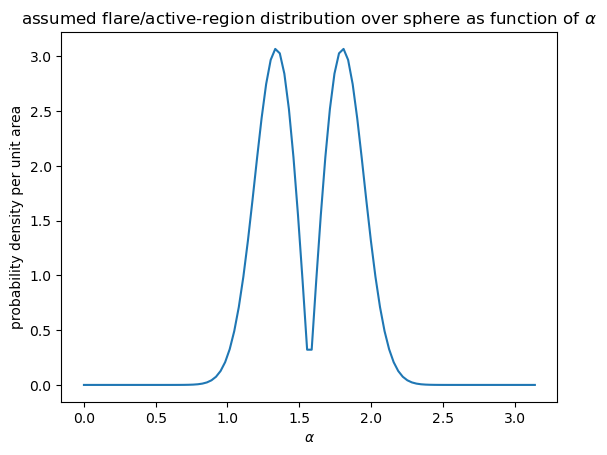

In [2]:
# general distribution of active regions per unit area (Sun, Rice-distribution fit)
def rice_dist(x, sigma, nu):
    x = np.abs(x)
    return x / sigma**2 * np.exp( - (x**2 + nu **2 ) / (2 * sigma **2)) * sc.iv(0, (x * nu / sigma**2))

sigma_fit, nu_fit = (9.02769086 / 180 * np.pi, 10.48768514 / 180 * np.pi)
Rn = 1
def rho(alpha, err=0.01):
    return rice_dist(np.pi / 2 - alpha, sigma_fit, nu_fit)  / (np.sin(alpha) + err) / Rn
            # fit of dist when integrated over phi and absolute value so accounting for that

alpha = np.linspace(0, np.pi, 100)
plt.plot(alpha, rho(alpha))
plt.title(r"assumed flare/active-region distribution over sphere as function of $\alpha$")
plt.xlabel(r"$\alpha$")
plt.ylabel('probability density per unit area')


## CME ejection-angle distribution for a given spread

As in `CME_distribution.ipynb`, the distribution of CMEs as a function of the angle $\theta'$ with the
zenith is assumed Gaussian and centred on the zenith (`loc=0`,
`rho_CME(theta2, loc=0, scale=0.2)`); here we keep that centring fixed and instead vary the *spread*
(`scale`, i.e. the standard deviation of the ejection angle around the zenith) as the free parameter
per scenario. Each distribution is properly normalised over the hemisphere $\theta' \in [0, \pi/2]$.

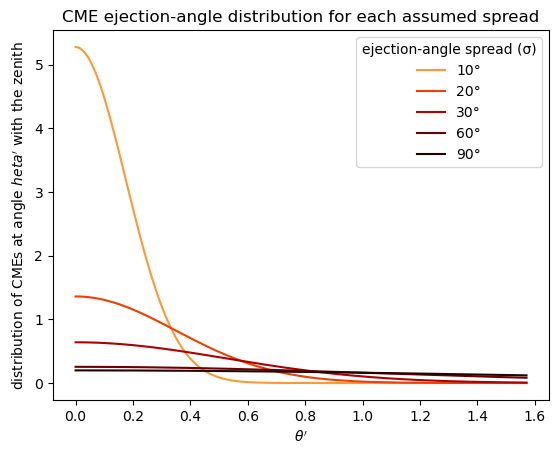

In [3]:
def make_rho_CME(scale, loc=0):
    """Build a normalised CME ejection-angle distribution centred on the zenith (loc=0) with the given spread `scale` (radians)."""
    def rho_CME_unnorm(theta2):
        return norm.pdf(theta2, loc, scale)

    f = lambda theta2: rho_CME_unnorm(theta2) * np.sin(theta2) * 2 * np.pi
    N = quad(f, 0, np.pi / 2)[0]

    def rho_CME(theta2):
        return rho_CME_unnorm(theta2) / N
    return rho_CME


output_spreads_deg = [10, 20, 30, 60, 90]
rho_CME_of_angle = {deg: make_rho_CME(deg / 180 * np.pi) for deg in output_spreads_deg}

cmap = plt.get_cmap("gist_heat_r")
colors = cmap(np.linspace(0.2, 0.9, len(output_spreads_deg)))
color_of_angle = dict(zip(output_spreads_deg, colors))

T = np.linspace(0, np.pi / 2, 200)
for deg, rho_CME in rho_CME_of_angle.items():
    plt.plot(T, [rho_CME(t) for t in T], color=color_of_angle[deg], label=f"{deg}°")
plt.xlabel(r"$\theta'$")
plt.ylabel("distribution of CMEs at angle $\theta'$ with the zenith")
plt.title("CME ejection-angle distribution for each assumed spread")
plt.legend(title="ejection-angle spread (σ)")


## Distribution of CMEs in viewing angle $\beta$ for given $\tau$

We reuse the same reduction of the four-fold integral over $(\theta, \phi, \theta', \phi')$ derived in
`CME_distribution.ipynb` (the $\phi'$ integral is done analytically against the delta function):

\begin{equation}
    \rho_\beta(\beta) = \frac{1}{N} \int_{[0,\pi] \times [0,2\pi] \times [0,\pi] }d\theta d\phi d\theta'
    \rho (\alpha(\theta, \phi))   \rho^{CME}(\theta')  \frac{|\sin\beta|}{2\,|\sin\theta\sin\theta'\sin\phi'(\theta, \theta', \beta)|}
\end{equation}


`CME_distribution.ipynb` evaluates this with `scipy.integrate.nquad`, which needs a low tolerance
(`epsrel=0.05`) and is *very* slow — the corrected $1/\sin\phi'$ form has a genuine, if integrable,
singularity at the domain boundary, so a single `nquad` evaluation can exceed two minutes. Since we need
to repeat the full calculation for 5 different ejection-angle scenarios (instead of 1), we instead use
the vectorised Monte Carlo estimator that the original notebook already mentions as the fast
alternative: we draw a scrambled Sobol' (quasi-random, low-discrepancy) sequence of $(\theta, \phi,
\theta')$ once per $\tau$ and evaluate the integrand for every $\beta$ at once — this covers the sampling
box more evenly than plain pseudo-random sampling, which noticeably reduces the point-to-point "wobble"
in the resulting curves for the same sample count (see `CME_distribution.ipynb` for details).

In [4]:
def get_alpha(tau, theta, phi):
    return np.arccos( np.sin( tau ) * np.sin(theta) * np.cos(phi) + np.cos(tau) * np.cos(theta))


def mc_rho_betas(betas, tau, rho_CME, m=23, seed=0):
    """Monte Carlo estimate of rho_beta(beta, tau) for every beta in `betas`, for a given rho_CME.

    Uses a scrambled Sobol' (quasi-random, low-discrepancy) sequence rather than plain
    pseudo-random sampling: since the same finite sample set is reused to evaluate every
    beta cut-point, plain Monte Carlo noise is correlated across beta (the same sample
    over/under-covers the same regions for every beta), which shows up as smooth spurious
    "wobble" in the resulting curve rather than independent point-to-point scatter. Sobol'
    sampling covers the (theta, phi, theta2) box far more evenly, which directly reduces
    that correlated wobble (~2-3x lower noise than pseudo-random at the same sample count,
    measured by comparing independent seeds). m=23 means 2**23 (~8.4M) samples. See
    CME_distribution.ipynb for the same estimator with more detail.
    """
    sampler_ = qmc.Sobol(d=3, scramble=True, seed=seed)
    u = sampler_.random_base2(m=m)
    theta = (u[:, 0] * np.pi)[:, None]
    phi = (u[:, 1] * 2 * np.pi)[:, None]
    theta2 = (u[:, 2] * np.pi / 2)[:, None]
    betas = np.asarray(betas)[None, :]

    alpha = get_alpha(tau, theta, phi)

    denom = np.sin(theta) * np.sin(theta2)
    cosphi2 = (np.cos(betas) - np.cos(theta) * np.cos(theta2)) / denom
    valid = np.abs(cosphi2) <= 1
    sinphi2 = np.where(valid, np.sqrt(np.clip(1 - cosphi2**2, 0, None)), 0.0)

    mask = (betas >= theta - theta2) & (betas <= theta + theta2) & (sinphi2 > 1e-6)
    safe_sinphi2 = np.where(mask, sinphi2, 1.0)
    # corrected: sin(phi') in the denominator (was the numerator); sin(theta), sin(theta2)
    # cancel against the measure and no longer appear. See CME_distribution.ipynb for the derivation.
    integrand = np.where(mask, rho(alpha) * rho_CME(theta2) / safe_sinphi2, 0.0)

    volume = np.pi * (2 * np.pi) * (np.pi / 2)   # volume of the (theta, phi, theta2) sampling box
    mean_val = integrand.mean(axis=0) * volume
    # corrected: multiply by |sin(beta)| (was dividing by it)
    return mean_val * np.abs(np.sin(betas.ravel())) / 2


betas = np.linspace(0, np.pi / 2, 20)
Taus = np.linspace(0, np.pi / 2, 5)
x = np.linspace(0, np.pi, 300)

In [5]:
def get_or_create_data(name, compute_fn):
    filename = f'calculations/{name}.npy'
    file_path = Path(filename)

    if file_path.exists():
        print(f"File '{filename}' found.")
        data = np.load(filename)
    else:
        print(f"File '{filename}' not found. Creating new data...")
        data = compute_fn()
        np.save(filename, data)
        print(f"Data saved to '{filename}'.")

    return data


def speed2beta(v):
    return np.arccos(v / 600)

def beta2speed(beta):
    return np.cos(beta) * 600


def plotting_(dens, taus, cmap_name="gist_heat_r"):
    cmap = plt.get_cmap(cmap_name)
    colors = cmap(np.linspace(0.2, 0.9, len(taus)))
    for c, (i, d) in zip(colors, enumerate(dens)):
        smooth_curve = make_interp_spline(betas, d / (np.average(d) * np.pi))(x)
        plt.plot(x, smooth_curve, color=c, label=fr"$\tau=${round(taus[i]/np.pi*180)}°")
    plt.plot(x, np.sin(x) / 2, "--", color='tab:red', label="mean")

    plt.legend()
    plt.xticks(np.linspace(0, np.pi / 2, 7), range(0, 91, 15))
    ax = plt.gca()
    secax = ax.secondary_xaxis('top', functions=(beta2speed, speed2beta))
    secax.set_xlabel(r'$\cos \beta \times 600$ km/s ')
    plt.xlabel(r"$\beta$ [°]")
    plt.ylabel(r"density []")
    plt.xlim(0, np.pi / 2)
    plt.ylim(0, 1)


### Run the calculation for each ejection-angle spread

For every assumed spread we compute $\rho_\beta(\beta)$ across the same 5 stellar
orientations $\tau$ used in `CME_distribution.ipynb`, and cache the result to `calculations/` so the
notebook does not need to redo the (still fairly expensive) sampling on every run.

File 'calculations/output_angle_10deg.npy' found.


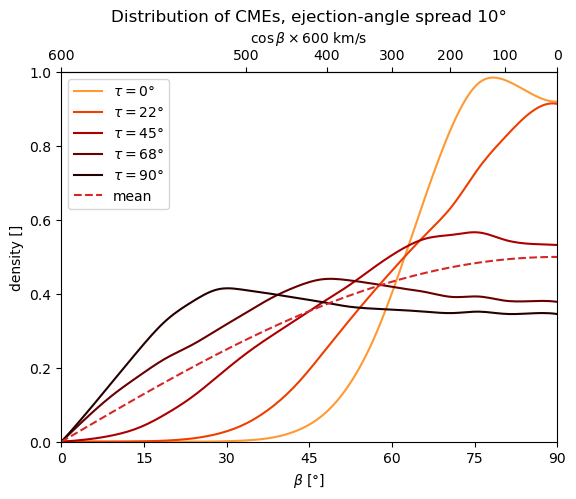

File 'calculations/output_angle_20deg.npy' found.


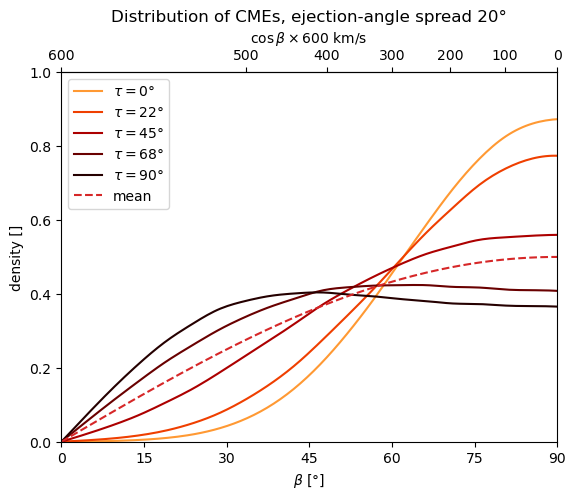

File 'calculations/output_angle_30deg.npy' not found. Creating new data...
Data saved to 'calculations/output_angle_30deg.npy'.


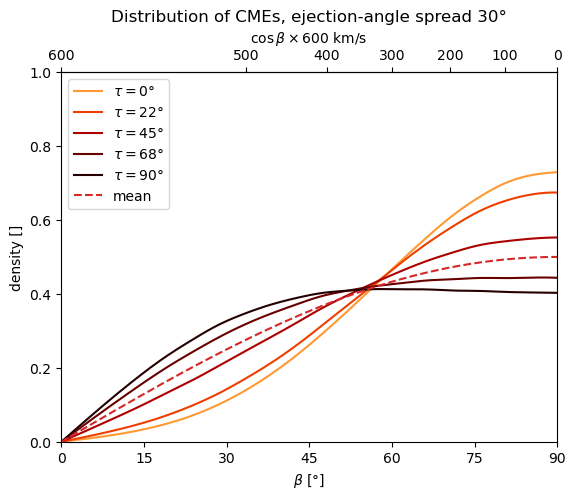

File 'calculations/output_angle_60deg.npy' found.


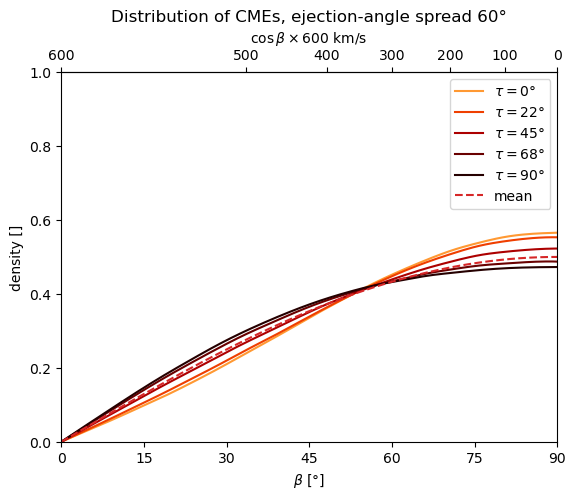

File 'calculations/output_angle_90deg.npy' found.


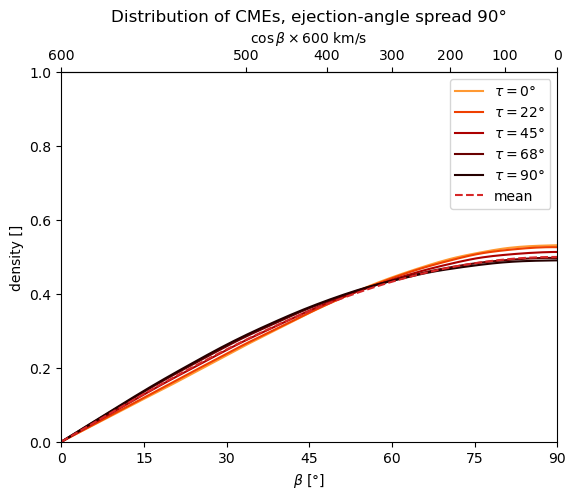

In [6]:
dens_of_angle = {}

for deg in output_spreads_deg:
    rho_CME = rho_CME_of_angle[deg]

    def compute_fn(rho_CME=rho_CME):
        return np.array([mc_rho_betas(betas, tau, rho_CME) for tau in Taus])

    dens = get_or_create_data(f"output_angle_{deg}deg", compute_fn)
    dens_of_angle[deg] = dens

    plotting_(dens, Taus)
    plt.title(f"Distribution of CMEs, ejection-angle spread {deg}°")
    plt.show()


## Comparing ejection-angle spreads at fixed stellar orientation

To isolate the effect of the ejection-angle-spread assumption from the effect of the (unknown) stellar
orientation $\tau$, we now fix $\tau$° and overlay the resulting
$\beta$ distribution for every spread. 

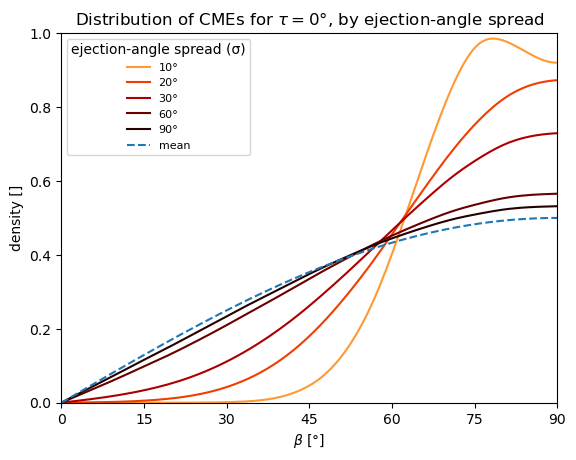

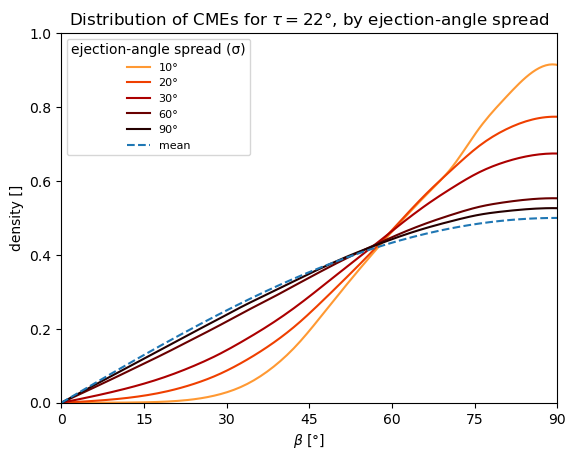

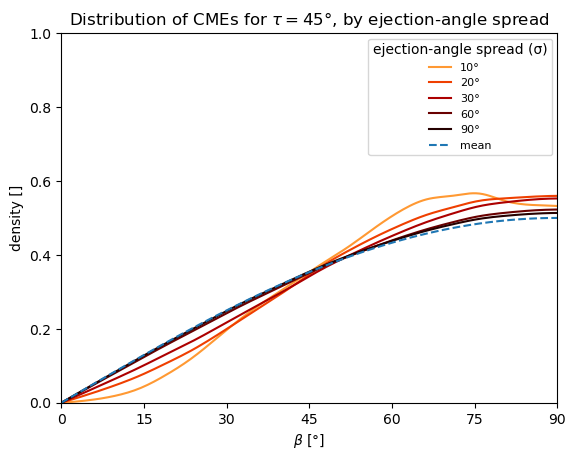

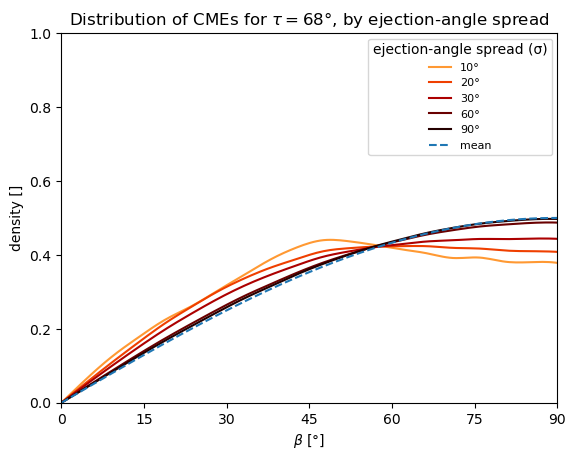

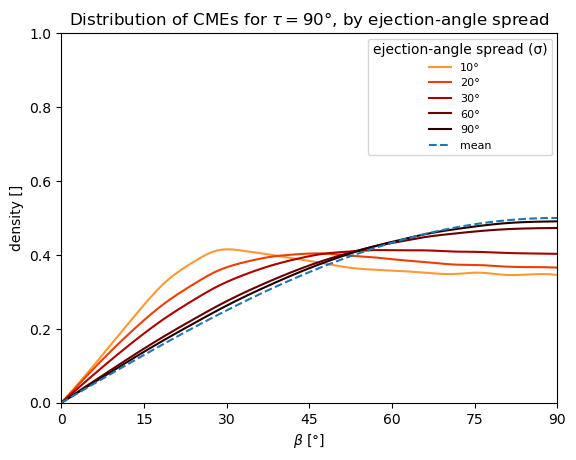

In [7]:
for tau_index in range(5):
    sundist = np.load('calculations/sundist.npy')
    all_curves = { **dens_of_angle}

    cmap = plt.get_cmap("gist_heat_r")
    colors = cmap(np.linspace(0.2, 0.9, len(all_curves)))

    for c, (deg, dens) in zip(colors, sorted(all_curves.items())):
        d = dens[tau_index]
        smooth_curve = make_interp_spline(betas, d / (np.average(d) * np.pi))(x)
        label = f"{deg}°"
        plt.plot(x, smooth_curve, color=c, label=label)

    plt.plot(x, np.sin(x) / 2, "--", color='tab:blue', label="mean")
    plt.legend(title="ejection-angle spread (σ)", fontsize=8)
    plt.xticks(np.linspace(0, np.pi / 2, 7), range(0, 91, 15))
    plt.title(fr"Distribution of CMEs for $\tau=${round(Taus[tau_index]/np.pi*180)}°, by ejection-angle spread")
    plt.xlabel(r"$\beta$ [°]")
    plt.ylabel(r"density []")
    plt.xlim(0, np.pi / 2)
    plt.ylim(0, 1)
    plt.show()
